In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import time

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [3]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    "./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    "./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.81MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 160kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.84MB/s]


In [4]:
class SparseAutoEncoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(

            nn.Flatten(),

            nn.Linear(784,256),
            nn.ReLU(),

            nn.Linear(256,128),
            nn.ReLU(),

            nn.Linear(128,64),
            nn.ReLU()

        )

        self.decoder = nn.Sequential(

            nn.Linear(64,128),
            nn.ReLU(),

            nn.Linear(128,256),
            nn.ReLU(),

            nn.Linear(256,784),

            nn.Sigmoid()

        )

    def forward(self,x):

        latent = self.encoder(x)

        reconstruction = self.decoder(latent)

        reconstruction = reconstruction.view(-1,1,28,28)

        return reconstruction, latent

In [5]:
model = SparseAutoEncoder().to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [6]:
def sparsity_penalty(latent):

    return torch.mean(torch.abs(latent))

In [7]:
epochs = 10

lambda_sparse = 1e-3

loss_history = []

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images,_ in train_loader:

        images = images.to(device)

        reconstruction, latent = model(images)

        reconstruction_loss = criterion(
            reconstruction,
            images
        )

        sparse_loss = sparsity_penalty(latent)

        loss = reconstruction_loss + lambda_sparse * sparse_loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    loss_history.append(epoch_loss)

    print(
        f"Epoch {epoch+1}/{epochs} Loss: {epoch_loss:.5f}"
    )

Epoch 1/10 Loss: 0.05562
Epoch 2/10 Loss: 0.02590
Epoch 3/10 Loss: 0.02015
Epoch 4/10 Loss: 0.01693
Epoch 5/10 Loss: 0.01486
Epoch 6/10 Loss: 0.01338
Epoch 7/10 Loss: 0.01223
Epoch 8/10 Loss: 0.01130
Epoch 9/10 Loss: 0.01052
Epoch 10/10 Loss: 0.00994


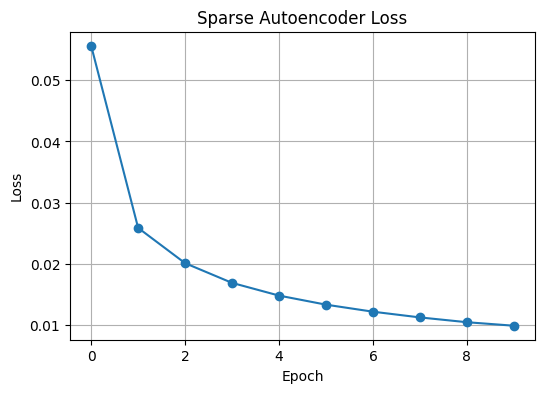

In [8]:
plt.figure(figsize=(6,4))

plt.plot(loss_history, marker="o")

plt.title("Sparse Autoencoder Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

In [9]:
model.eval()

image, label = next(iter(test_loader))

image = image.to(device)

start = time.time()

with torch.no_grad():

    reconstruction, latent = model(image)

end = time.time()

print("Inference Time:", end-start)

Inference Time: 0.006499767303466797


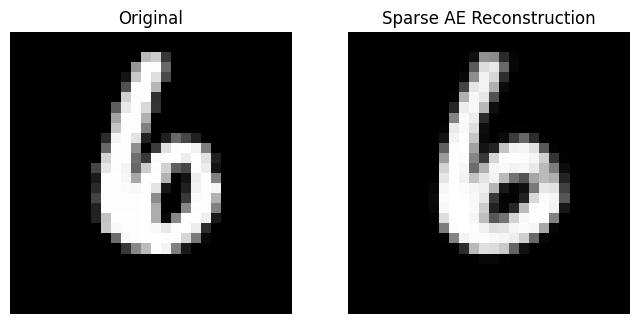

In [10]:
original = image.cpu().squeeze().numpy()

reconstructed = reconstruction.cpu().squeeze().numpy()

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)

plt.imshow(original,cmap="gray")

plt.title("Original")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(reconstructed,cmap="gray")

plt.title("Sparse AE Reconstruction")

plt.axis("off")

plt.show()

In [11]:
mse = np.mean((original-reconstructed)**2)

print("Reconstruction Error:", mse)

Reconstruction Error: 0.0067140325


In [12]:
print("Latent Shape:", latent.shape)

print(latent)

Latent Shape: torch.Size([1, 64])
tensor([[1.3567, 0.4648, 0.5675, 3.0974, 0.5525, 1.6614, 1.4085, 0.0000, 1.1724,
         0.0000, 0.0000, 0.0000, 0.5537, 0.9632, 0.0000, 0.6826, 0.0000, 0.5282,
         0.6110, 0.0000, 1.3989, 0.0000, 0.0000, 0.0000, 0.8364, 0.0000, 0.4922,
         0.0000, 0.7542, 0.7509, 2.6127, 0.7352, 2.9495, 0.0000, 0.0000, 0.0000,
         0.6897, 0.0000, 0.6445, 1.5728, 2.4656, 0.5320, 1.1205, 0.0000, 0.0000,
         0.0000, 0.7537, 0.4818, 0.0000, 0.5009, 0.0000, 1.7464, 0.0000, 1.5255,
         0.0000, 0.0000, 0.2908, 0.0000, 1.6302, 0.0000, 1.9921, 1.3160, 1.8985,
         0.0000]])


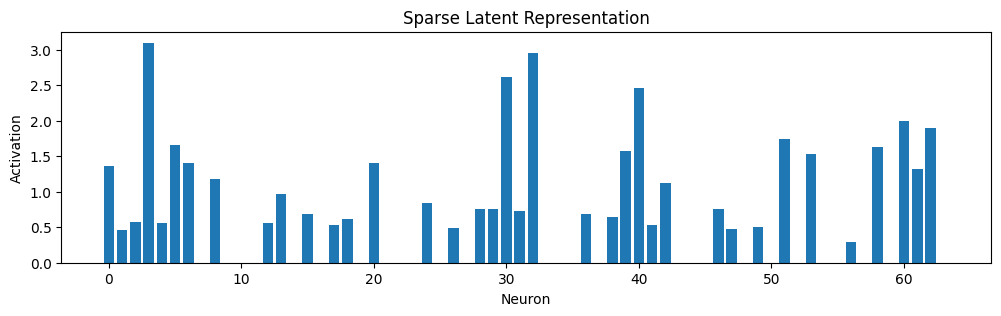

In [13]:
latent_np = latent.cpu().numpy().flatten()

plt.figure(figsize=(12,3))

plt.bar(range(len(latent_np)), latent_np)

plt.title("Sparse Latent Representation")

plt.xlabel("Neuron")

plt.ylabel("Activation")

plt.show()

In [14]:
threshold = 0.01

active = np.sum(np.abs(latent_np) > threshold)

print("Total Latent Neurons :", len(latent_np))
print("Active Neurons       :", active)
print("Inactive Neurons     :", len(latent_np)-active)

Total Latent Neurons : 64
Active Neurons       : 37
Inactive Neurons     : 27


In [15]:
torch.save(
    model.state_dict(),
    "sparse_autoencoder_mnist.pth"
)

print("Sparse Autoencoder saved.")

Sparse Autoencoder saved.
